# GBM Grid Search - FX Pairs

Can gradient boosting capture non-linear interactions among momentum, volatility,
carry proxies, and temporal state that linear models miss? This notebook compares
tree capacity and robust losses for one-day FX cross-sectional forecasts.

**Learning Objectives**:
- Test whether non-linear feature interactions improve on the linear baseline
- Compare loss functions (MSE, MAE, Huber) on noisy daily FX returns
- Compare validation IC across tree counts without touching the sealed holdout
- Generate backtesting-ready predictions for downstream portfolio construction

**Book Reference**: Chapter 12, Section 12.2 (GBM Libraries)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb), and
[`02_labels`](02_labels.ipynb)

In [1]:
"""GBM Grid Search - config-driven regularization profiles x loss functions."""

import json

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic

from case_studies.utils.gbm import (
    prepare_gbm_folds,
    register_gbm_result,
    train_gbm_config,
)
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_sets,
    read_predictions,
    training_hash_from_spec,
    training_run_status,
)
from utils.cv_splits import generate_cv_splits
from utils.modeling import ConfigError, load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "fx_pairs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Device: read from setup.yaml, fall back to GPU detection.
gbm_config = setup.get("modeling", {}).get("gbm", {})
DEVICE = gbm_config.get("device", "cuda")
MAX_BIN = 63  # GPU default

if DEVICE != "cpu" and not torch.cuda.is_available():
    DEVICE, MAX_BIN = "cpu", 255

print(f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | max_bin: {MAX_BIN}")

Case study: fx_pairs | Device: gpu | max_bin: 63


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm:` key.
Each config references a preset in `config/lgb/` with the complete
LightGBM parameter set. To modify the grid, edit the label config file.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"

# Temporal features are fitted to the primary-label boundaries materialized by
# notebooks 02 and 04. Variant labels need embargo-specific temporal artifacts.
if setup["labels"]["primary"] != PRIMARY_LABEL:
    raise ConfigError(
        f"{PRIMARY_LABEL!r} has no matching fold-aware temporal artifact. "
        f"Run this notebook with the primary label {setup['labels']['primary']!r}."
    )
cv_config = json.loads((CASE_DIR / "config" / "cv_config.json").read_text())
splits = generate_cv_splits(
    dataset,
    cv_config=cv_config,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
splits = [
    {
        **split,
        **{
            key: pd.Timestamp(split[key])
            for key in ("train_start", "train_end", "val_start", "val_end")
        },
    }
    for split in splits[: MAX_FOLDS or None]
]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 77,440 rows × 61 features
Label: fwd_ret_1d | Task: regression | Folds: 8


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")
config_table = pl.DataFrame(
    [
        {
            "config": cfg["config_name"],
            "leaves": cfg["params"].get("num_leaves", 31),
            "objective": cfg["params"].get("objective", "regression"),
            "trees": cfg.get("max_iterations", 500),
        }
        for cfg in configs
    ]
)
print(f"\n{len(configs)} configs x {len(splits)} folds")
config_table


15 configs x 8 folds


config,leaves,objective,trees
str,i64,str,i64
"""default_mse""",31,"""regression""",500
"""default_mae""",31,"""regression_l1""",500
"""default_huber""",31,"""huber""",500
"""leaves_7_mse""",7,"""regression""",500
"""leaves_7_mae""",7,"""regression_l1""",500
…,…,…,…
"""leaves_31_mae""",31,"""regression_l1""",500
"""leaves_31_huber""",31,"""huber""",500
"""leaves_63_mse""",63,"""regression""",500


## 2. Prepare CV Folds

GBM folds use float32, the native LightGBM precision. Their boundaries come
from `cv_config.json`, so each fold ID selects the matching temporal artifact.
LightGBM handles ordinary feature missingness without imputation or scaling.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in fold_data:
    missing_temporal = [
        feature_names[idx]
        for idx in (feature_names.index(name) for name in mds.temporal_feature_names)
        if np.isnan(f["X_train"][:, idx]).all() or np.isnan(f["X_val"][:, idx]).all()
    ]
    if f["X_train"].shape[1] != len(feature_names) or f["X_val"].shape[1] != len(feature_names):
        raise ConfigError(
            f"Fold {f['fold']} retained {f['X_train'].shape[1]}/{len(feature_names)} features."
        )
    if missing_temporal:
        raise ConfigError(
            f"Fold {f['fold']} has no observations for temporal features: {missing_temporal}"
        )
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=24,840  val=5,420
  Fold 1: train=25,940  val=5,300
  Fold 2: train=26,560  val=5,340
  Fold 3: train=26,920  val=4,600
  Fold 4: train=26,120  val=5,420
  Fold 5: train=26,160  val=5,400
  Fold 6: train=26,140  val=5,320
  Fold 7: train=26,160  val=5,360


## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints every 50 iterations. Selection
uses pooled daily IC over the validation dates, never the sealed holdout.

A complete frozen-registry entry reloads its prediction rows and learning curve.
With `FORCE_RETRAIN=True`, GPU results are fixed-seed but not bitwise reproducible;
exact reproduction requires LightGBM's deterministic CPU settings and a pinned environment.

Prediction quality is recomputed from prediction rows. This gives cached and
fresh paths the same daily-IC and full-coverage definitions.

In [7]:
def _prediction_quality(predictions):
    """Return daily IC summary and invalid prediction count."""
    summary = cross_sectional_ic(
        predictions,
        predictions,
        pred_col="y_score",
        ret_col="y_true",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    )
    n_invalid = predictions.select(
        (
            pl.col("y_score").is_null().sum()
            + pl.col("y_score").is_nan().sum()
            + pl.col("y_score").is_infinite().sum()
        ).alias("n_invalid")
    ).item()
    return summary, int(n_invalid)

Fresh checkpoint predictions are normalized to the registry's canonical schema
before daily IC is computed.

In [8]:
def _prediction_frame(entries):
    """Combine checkpoint entries into one canonical prediction table."""
    return pl.concat(
        [
            pl.DataFrame(
                {
                    "timestamp": entry["dates"],
                    "symbol": entry["entities"],
                    "fold_id": [entry["fold"]] * len(entry["y_pred"]),
                    "y_true": entry["y_true"],
                    "y_score": entry["y_pred"],
                }
            )
            for entry in entries
        ]
    )

Per-fold records are rebuilt at the newly selected checkpoint so registry
diagnostics cannot retain the shared trainer's pre-normalization choice.

In [9]:
def _fold_metrics(entries):
    """Build registry-ready metrics for one selected checkpoint."""
    train_rows = {fold["fold"]: fold["n_train"] for fold in fold_data}
    rows = []
    for entry in entries:
        predictions = _prediction_frame([entry])
        summary, _ = _prediction_quality(predictions)
        rows.append(
            {
                "fold_id": entry["fold"],
                "ic_mean": float(summary["ic_mean"]),
                "n_train": train_rows[entry["fold"]],
                "n_test": predictions.height,
            }
        )
    return rows

The shared trainer exposes every checkpoint. Re-aggregating those rows here
keeps unequal fold lengths from weighting each fold equally and requires full
daily coverage when selecting the best checkpoint.

In [10]:
def _normalize_gbm_result(result):
    """Select a full-coverage checkpoint using pooled daily IC."""
    checkpoints = sorted({entry["n_trees"] for entry in result["predictions"]})
    curves = []
    for checkpoint in checkpoints:
        entries = [e for e in result["predictions"] if e["n_trees"] == checkpoint]
        summary, n_invalid = _prediction_quality(_prediction_frame(entries))
        curves.append(
            {
                "config": result["config_name"],
                "iteration": checkpoint,
                "ic_mean": float(summary["ic_mean"]),
                "ic_std": float(summary["ic_std"]),
                "ic_n_days": float(summary["n_periods"]),
                "n_invalid": n_invalid,
            }
        )
    valid_curves = [
        curve
        for curve in curves
        if curve["n_invalid"] == 0
        and np.isfinite(curve["ic_n_days"])
        and curve["ic_n_days"] > 0
        and np.isfinite(curve["ic_mean"])
    ]
    if not valid_curves:
        raise ConfigError(f"{result['config_name']} has no valid full-coverage checkpoint")
    full_days = max(curve["ic_n_days"] for curve in valid_curves)
    eligible = [curve for curve in valid_curves if curve["ic_n_days"] == full_days]
    if not eligible:
        raise ConfigError(f"{result['config_name']} has no full-coverage checkpoint")
    best_curve = max(eligible, key=lambda curve: curve["ic_mean"])
    best_entries = [
        entry for entry in result["predictions"] if entry["n_trees"] == best_curve["iteration"]
    ]
    result.update(
        best_iter=best_curve["iteration"],
        best_ic=best_curve["ic_mean"],
        best_ic_std=best_curve["ic_std"],
        ic_n_days=best_curve["ic_n_days"],
        n_invalid=best_curve["n_invalid"],
        learning_curves=curves,
        fold_metrics=_fold_metrics(best_entries),
    )
    return result

Cached entries carry the frozen selected checkpoint. Its mean IC, dispersion,
coverage, and null count are rebuilt from the immutable prediction parquet.
Legacy rows without checkpoint metadata recover the selection from the frozen curve.

In [11]:
def _cached_gbm_result(cfg, train_dir, split_rows):
    """Reconstruct one complete cached result from prediction artifacts."""
    predictions = read_predictions(CASE_STUDY_ID, split_rows["prediction_hash"][0])
    summary, n_invalid = _prediction_quality(predictions)
    curve_path = train_dir / "learning_curves.parquet"
    curves = pl.read_parquet(curve_path).to_dicts() if curve_path.exists() else []
    checkpoint_value = split_rows["checkpoint_value"][0]
    if checkpoint_value is None:
        if not curves:
            raise ConfigError(f"{cfg['config_name']} has no cached checkpoint metadata")
        checkpoint_value = max(curves, key=lambda curve: curve["ic_mean"])["iteration"]
    best_iter = int(checkpoint_value)
    return {
        "config_name": cfg["config_name"],
        "best_iter": best_iter,
        "best_ic": float(summary["ic_mean"]),
        "best_ic_std": float(summary["ic_std"]),
        "ic_n_days": float(summary["n_periods"]),
        "n_invalid": n_invalid,
        "elapsed_s": 0.0,
        "learning_curves": curves,
        "cached": True,
    }

Each configuration either reloads a complete cache or trains and registers
immediately, so an interrupted sweep retains completed work.

In [12]:
def _run_config(cfg):
    """Load or train one GBM configuration."""
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=cfg.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    status = training_run_status(CASE_STUDY_ID, spec)
    split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash_from_spec(spec),
        split=PREDICTION_SPLIT,
    )
    if status.complete and not split_rows.is_empty() and not FORCE_RETRAIN:
        return _cached_gbm_result(cfg, train_dir, split_rows), f"cached, {status.summary()}"
    if status.complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    elif status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {status.summary()}")
    result = _normalize_gbm_result(
        train_gbm_config(
            cfg,
            fold_data,
            feature_names=feature_names,
            device=DEVICE,
            max_bin=MAX_BIN,
            entity_col=entity_col,
            date_col=date_col,
            task_type=mds.task_type,
            class_values=mds.class_values,
            save_dir=train_dir,
        )
    )
    register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="07_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
    )
    return result, f"trained in {result['elapsed_s']:.0f}s"

In [13]:
results = []
for cfg in configs:
    result, source = _run_config(cfg)
    results.append(result)
    print(
        f"  {result['config_name']:25s}  iter={result['best_iter']:4d}  "
        f"IC={result['best_ic']:+.4f}  ({source})"
    )

  default_mse                iter= 450  IC=-0.0061  (cached, complete (hash=e7cfd4c50bf1))
  default_mae                iter= 200  IC=-0.0037  (cached, complete (hash=04465134656f))
  default_huber              iter= 100  IC=-0.0062  (cached, complete (hash=fc13e8f78982))
  leaves_7_mse               iter= 200  IC=-0.0012  (cached, complete (hash=93e818183439))
  leaves_7_mae               iter= 400  IC=-0.0084  (cached, complete (hash=285bd82bc82d))
  leaves_7_huber             iter= 500  IC=-0.0006  (cached, complete (hash=d26a2dff95ac))
  leaves_15_mse              iter= 200  IC=-0.0050  (cached, complete (hash=c439880f6f9e))


  leaves_15_mae              iter= 400  IC=+0.0022  (cached, complete (hash=888ec61bf37f))


  leaves_15_huber            iter= 250  IC=+0.0003  (cached, complete (hash=02e1237e1dbf))
  leaves_31_mse              iter=  50  IC=-0.0027  (cached, complete (hash=00192bc9b41d))
  leaves_31_mae              iter= 500  IC=+0.0015  (cached, complete (hash=6a4c19e80a22))
  leaves_31_huber            iter= 100  IC=-0.0031  (cached, complete (hash=64c7b704a232))
  leaves_63_mse              iter= 450  IC=+0.0022  (cached, complete (hash=e57e873f904c))
  leaves_63_mae              iter= 150  IC=+0.0025  (cached, complete (hash=db18b7e165f5))
  leaves_63_huber            iter= 250  IC=-0.0017  (cached, complete (hash=6f9a44b9c36f))


## 4. Grid Results

Rank only configurations with zero invalid predictions and the maximum number
of positive, valid daily IC observations. Zero-day or non-finite summaries are
invalid results, not complete runs. This prevents an incomplete run from winning.

In [14]:
eligible_results = [
    r
    for r in results
    if r.get("n_invalid", 1) == 0
    and np.isfinite(r.get("ic_n_days", np.nan))
    and r["ic_n_days"] > 0
    and np.isfinite(r.get("best_ic", np.nan))
]
if not eligible_results:
    raise ConfigError("No GBM configuration has valid daily coverage")
full_days = max(r["ic_n_days"] for r in eligible_results)
full_results = sorted(
    (r for r in eligible_results if r["ic_n_days"] == full_days),
    key=lambda r: r["best_ic"],
    reverse=True,
)
full_names = {r["config_name"] for r in full_results}
excluded = [r for r in results if r["config_name"] not in full_names]
best = full_results[0]
print(
    f"Full validation coverage: {len(full_results)}/{len(results)} configs x {int(full_days):,} days"
)
print(f"Best: {best['config_name']} @ {best['best_iter']} trees (IC={best['best_ic']:+.4f})")
if excluded:
    print("Excluded incomplete configs: " + ", ".join(r["config_name"] for r in excluded))

Full validation coverage: 15/15 configs x 2,064 days
Best: leaves_63_mae @ 150 trees (IC=+0.0025)


### The frozen GBM grid does not improve on the linear benchmark

The selected checkpoint from each configuration provides the fairest grid-level
comparison. The amber bar marks the frozen winner; the zero line separates weak
positive rankings from configurations that reverse the cross-section.

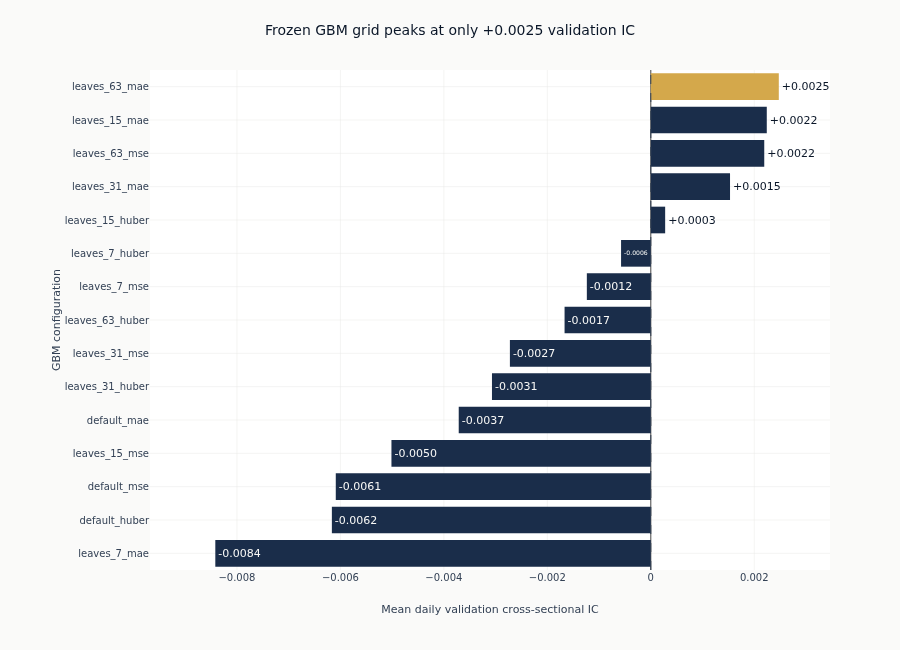

In [15]:
bar_results = list(reversed(full_results))
fig_grid = go.Figure(
    go.Bar(
        x=[r["best_ic"] for r in bar_results],
        y=[r["config_name"] for r in bar_results],
        orientation="h",
        marker_color=[
            COLORS["amber"] if r["config_name"] == best["config_name"] else COLORS["slate"]
            for r in bar_results
        ],
        text=[f"{r['best_ic']:+.4f}" for r in bar_results],
        textposition=["outside" if r["best_ic"] >= 0 else "inside" for r in bar_results],
        textfont_color=[
            COLORS["blue"] if r["best_ic"] >= 0 else COLORS["silver"] for r in bar_results
        ],
    )
)
fig_grid.add_vline(x=0, line_color=COLORS["neutral"], line_dash="dash", line_width=1)
fig_grid.update_layout(
    title=f"Frozen GBM grid peaks at only {best['best_ic']:+.4f} validation IC",
    height=650,
    width=900,
    showlegend=False,
    margin=dict(l=150, r=70, t=70),
)
fig_grid.update_xaxes(
    title_text="Mean daily validation cross-sectional IC",
    range=[
        min(r["best_ic"] for r in bar_results) * 1.15,
        max(r["best_ic"] for r in bar_results) * 1.4,
    ],
)
fig_grid.update_yaxes(title_text="GBM configuration")
fig_grid.show()

## 5. Learning Curves

The four leading configurations show whether additional trees stabilize or
erode validation ranking. All values are frozen v3.0 metrics; a retrain against
the corrected feature vintage belongs to the v3.1 results batch.

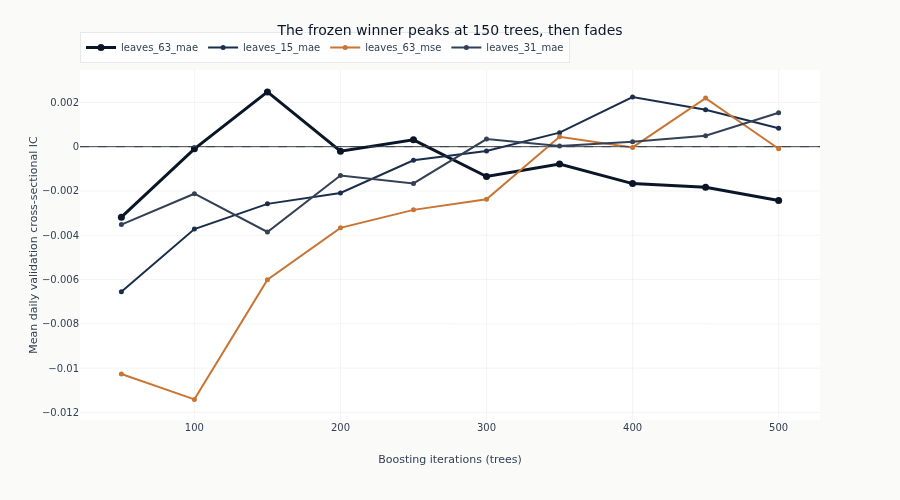

In [16]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
leaders = [r["config_name"] for r in full_results[:4]]
line_colors = [COLORS["blue"], COLORS["slate"], COLORS["copper"], COLORS["neutral"]]
fig_curves = go.Figure()
for rank, config_name in enumerate(leaders):
    curve = all_curves.filter(pl.col("config") == config_name).sort("iteration")
    fig_curves.add_trace(
        go.Scatter(
            x=curve["iteration"],
            y=curve["ic_mean"],
            mode="lines+markers",
            name=config_name,
            line=dict(color=line_colors[rank], width=3 if rank == 0 else 2),
            marker=dict(size=7 if rank == 0 else 5),
        )
    )
fig_curves.add_hline(y=0, line_color=COLORS["neutral"], line_dash="dash", line_width=1)
fig_curves.update_layout(
    title=f"The frozen winner peaks at {best['best_iter']} trees, then fades",
    height=500,
    width=900,
    margin=dict(t=70),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees)")
fig_curves.update_yaxes(title_text="Mean daily validation cross-sectional IC")
fig_curves.show()

**Interpretation**: the frozen `leaves_63_mae` checkpoint peaks at 150 trees
with IC `+0.0025`, then falls below zero by 500 trees. Ridge remains the stronger
one-day validation benchmark at `+0.0052`. MAE supplies three of the top four GBM
configurations, but the small magnitudes do not establish a reliable non-linear edge.

## 6. Registration Complete

Each config was registered immediately after training (see Section 3).
Cached reproduction writes nothing; a fresh run persists each completed config
incrementally in `run_log/registry.db`.

In [17]:
print(f"All {len(results)} configs available for analysis.")

All 15 configs available for analysis.


## 7. Key Takeaways

1. **Non-linearity does not improve the frozen one-day benchmark**: GBM peaks at
   `+0.0025`, below Ridge at `+0.0052`.
2. **The winning grid point is deep and robust**: `leaves_63_mae` leads, so the
   previous shallow-tree claim is not supported by this run.
3. **Checkpoint selection matters**: the winner peaks at 150 trees and turns
   negative by 500, showing how a fixed tree budget can conceal validation decay.
4. **The result remains a weak validation ranking**: all 15 configurations cover
   the same 2,064 frozen dates, but the best IC is still close to zero.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests a neural tabular ensemble on
the same one-day forecasting task.

**Book**: Chapter 12, Section 12.2 compares GBM engines and regularization choices.